# 🔧 Classificação de Configuração de Vibração em Motor
**Dataset:** Motor Failure Time Prediction (UCI)  
**Objetivo:** Classificar a configuração de peso (`wconfid`) a partir dos sinais brutos do acelerômetro, usando feature engineering baseado em janelas de tempo.

| wconfid | Configuração | Descrição |
|---------|-------------|----------|
| 1 | 🔴 Red (Normal) | Pesos em pás vizinhas |
| 2 | 🔵 Blue (Perpendicular) | Pesos a 90° |
| 3 | 🟢 Green (Oposto) | Pesos em pás opostas |

## 1. Imports e Configuração

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 2. Carregamento dos Dados

In [13]:
df = pd.read_csv('accelerometer.csv')  # <-- altere para o nome do seu arquivo

df.head()

,wconfid,pctid,x,y,z
0,1,20,1.004,0.090,-0.125
1,1,20,1.004,-0.043,-0.125
2,1,20,0.969,0.090,-0.121
3,1,20,0.973,-0.012,-0.137
4,1,20,1.000,-0.016,-0.121


## 3. Feature Engineering por Janelas de Tempo

O artigo original usa janelas de 50 observações (1 segundo a 20ms por leitura).  
Para cada janela, extraímos features estatísticas e do domínio da frequência (FFT).

**Features extraídas por eixo (x, y, z):**
- Domínio do tempo: média, desvio padrão, RMS, mínimo, máximo, skewness, kurtosis, peak-to-peak
- Domínio da frequência (FFT): amplitude RMS das frequências, frequência dominante, amplitude dominante

**Mais:** velocidade do cooler (`pctid`) como feature adicional

In [14]:
def extract_features(window: pd.DataFrame) -> dict:
    """Extrai features de uma janela de tempo para os eixos x, y, z."""
    features = {}
    
    # Feature de velocidade (constante na janela)
    features['pctid'] = window['pctid'].iloc[0]
    
    for axis in ['x', 'y', 'z']:
        signal = window[axis].values
        n = len(signal)
        
        # --- Domínio do Tempo ---
        features[f'{axis}_mean']   = np.mean(signal)
        features[f'{axis}_std']    = np.std(signal)
        features[f'{axis}_rms']    = np.sqrt(np.mean(signal**2))
        features[f'{axis}_min']    = np.min(signal)
        features[f'{axis}_max']    = np.max(signal)
        features[f'{axis}_p2p']    = np.max(signal) - np.min(signal)  # peak-to-peak
        features[f'{axis}_skew']   = skew(signal)
        features[f'{axis}_kurt']   = kurtosis(signal)  # sensível a impactos
        features[f'{axis}_energy'] = np.sum(signal**2) / n
        
        # --- Domínio da Frequência (FFT) ---
        fft_vals  = np.abs(fft(signal))[:n // 2]
        freqs     = fftfreq(n, d=0.02)[:n // 2]  # 20ms por amostra → fs=50Hz
        
        features[f'{axis}_fft_rms']        = np.sqrt(np.mean(fft_vals**2))
        features[f'{axis}_fft_dom_freq']   = freqs[np.argmax(fft_vals)]   # frequência dominante
        features[f'{axis}_fft_dom_amp']    = np.max(fft_vals)             # amplitude dominante
        features[f'{axis}_fft_spectral_entropy'] = (-np.sum((fft_vals / (fft_vals.sum() + 1e-10)) * np.log(fft_vals / (fft_vals.sum() + 1e-10) + 1e-10)))  # entropia espectral: mede regularidade do sinal
    
    return features


def build_feature_dataset(df: pd.DataFrame, window_size: int = 50) -> pd.DataFrame:
    """
    Aplica extração de features em janelas deslizantes.
    
    Estratégia: janelas sem sobreposição, agrupadas por (wconfid, pctid)
    para não misturar contextos diferentes numa mesma janela.
    """
    records = []
    
    for (wconfid, pctid), group in df.groupby(['wconfid', 'pctid']):
        group = group.reset_index(drop=True)
        n_windows = len(group) // window_size
        
        for i in range(n_windows):
            window = group.iloc[i * window_size : (i + 1) * window_size]
            feats = extract_features(window)
            feats['wconfid'] = wconfid
            records.append(feats)
    
    return pd.DataFrame(records)


print('⏳ Extraindo features por janelas de 50 observações (1s)...')
df_feat = build_feature_dataset(df, window_size=50)

print(f'✅ Dataset de features gerado!')
print(f'   Shape: {df_feat.shape}')
print(f'   Features por janela: {df_feat.shape[1] - 1}')
print(df_feat['wconfid'].value_counts().sort_index())
df_feat.head()

⏳ Extraindo features por janelas de 50 observações (1s)...
✅ Dataset de features gerado!
   Shape: (3060, 41)
   Features por janela: 40
wconfid
1    1020
2    1020
3    1020
Name: count, dtype: int64


,pctid,x_mean,x_std,x_rms,x_min,x_max,x_p2p,x_skew,x_kurt,x_energy,...,z_max,z_p2p,z_skew,z_kurt,z_energy,z_fft_rms,z_fft_dom_freq,z_fft_dom_amp,z_fft_spectral_entropy,wconfid
0,20,0.99298,0.019679,0.993175,0.961,1.039,0.078,0.363116,-0.590486,0.986397,...,-0.109,0.055,-0.576948,-0.163741,0.017125,1.305799,0.0,6.515,1.227108,1
1,20,0.99248,0.021650,0.992716,0.957,1.047,0.090,0.521790,-0.565715,0.985485,...,-0.105,0.051,-0.499209,-0.574880,0.016959,1.299393,0.0,6.483,1.085201,1
2,20,0.99584,0.021206,0.996066,0.957,1.039,0.082,0.139067,-0.904409,0.992147,...,-0.109,0.047,-0.434681,-0.889096,0.017545,1.321570,0.0,6.593,1.128778,1
3,20,0.99520,0.021390,0.995430,0.961,1.039,0.078,0.336154,-1.027200,0.990881,...,-0.109,0.047,-0.597348,-0.101197,0.017014,1.302317,0.0,6.502,1.010358,1
4,20,0.99254,0.023405,0.992816,0.953,1.039,0.086,0.352016,-0.815956,0.985683,...,-0.098,0.062,-0.303753,-0.308744,0.017293,1.311710,0.0,6.542,1.209322,1


<Axes: xlabel='pctid', ylabel='count'>

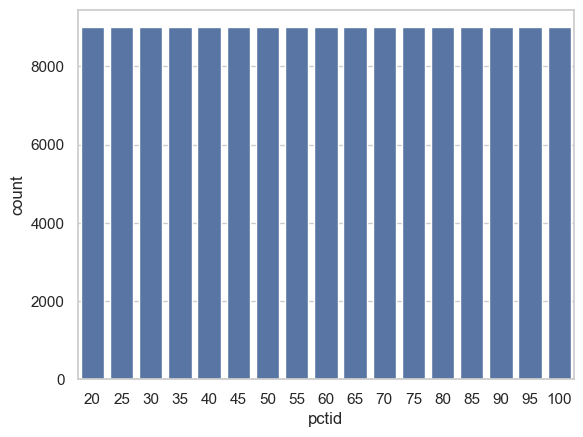

In [15]:
sns.countplot(data=df, x='pctid')

## 4. Análise das Features

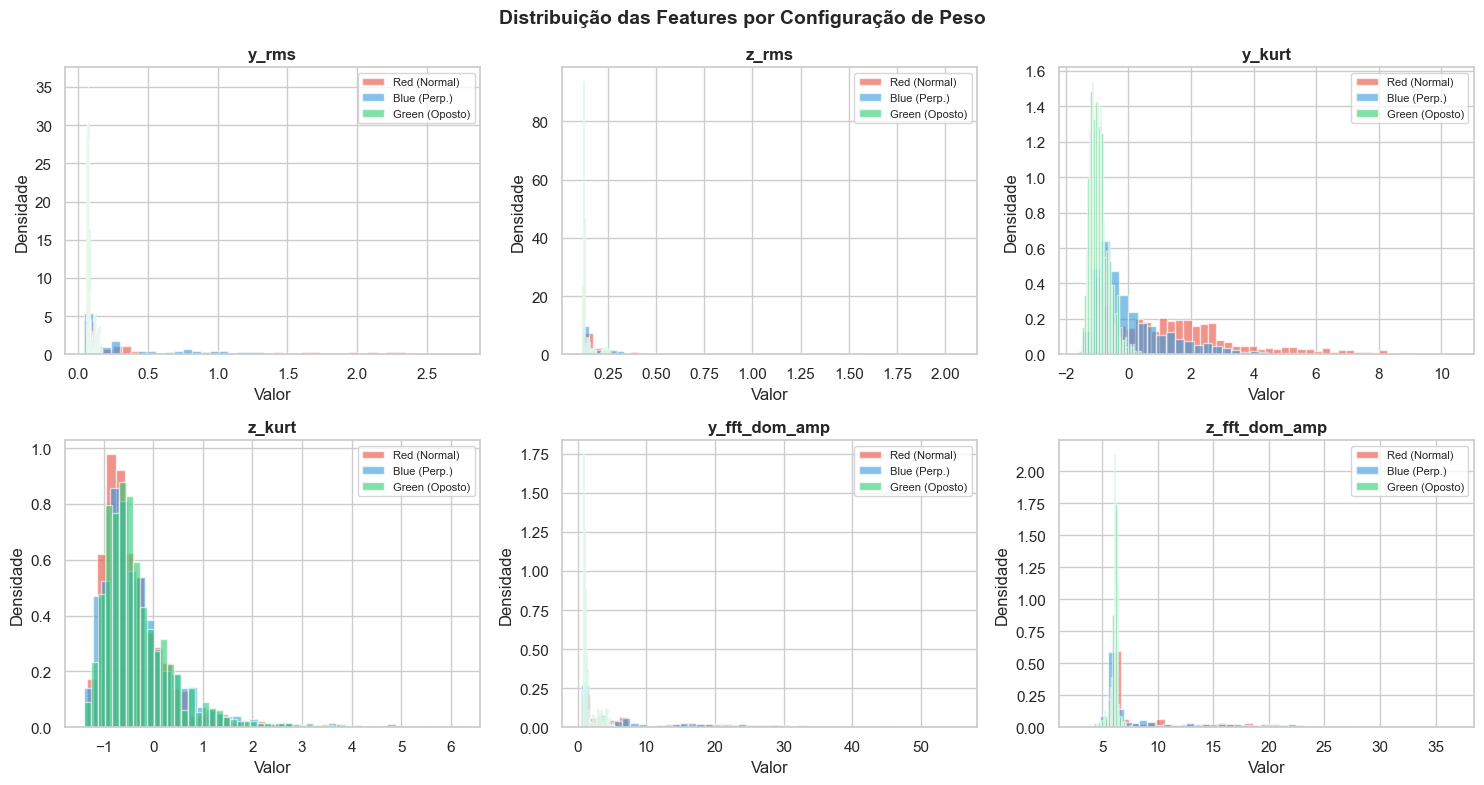

In [16]:
# Distribuição das features mais relevantes por classe
key_features = ['y_rms', 'z_rms', 'y_kurt', 'z_kurt', 'y_fft_dom_amp', 'z_fft_dom_amp']
config_names = {1: 'Red (Normal)', 2: 'Blue (Perp.)', 3: 'Green (Oposto)'}
colors = {1: '#e74c3c', 2: '#3498db', 3: '#2ecc71'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for wconfid, label in config_names.items():
        subset = df_feat[df_feat['wconfid'] == wconfid][feat]
        ax.hist(subset, bins=40, alpha=0.6, label=label, color=colors[wconfid], density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Features por Configuração de Peso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

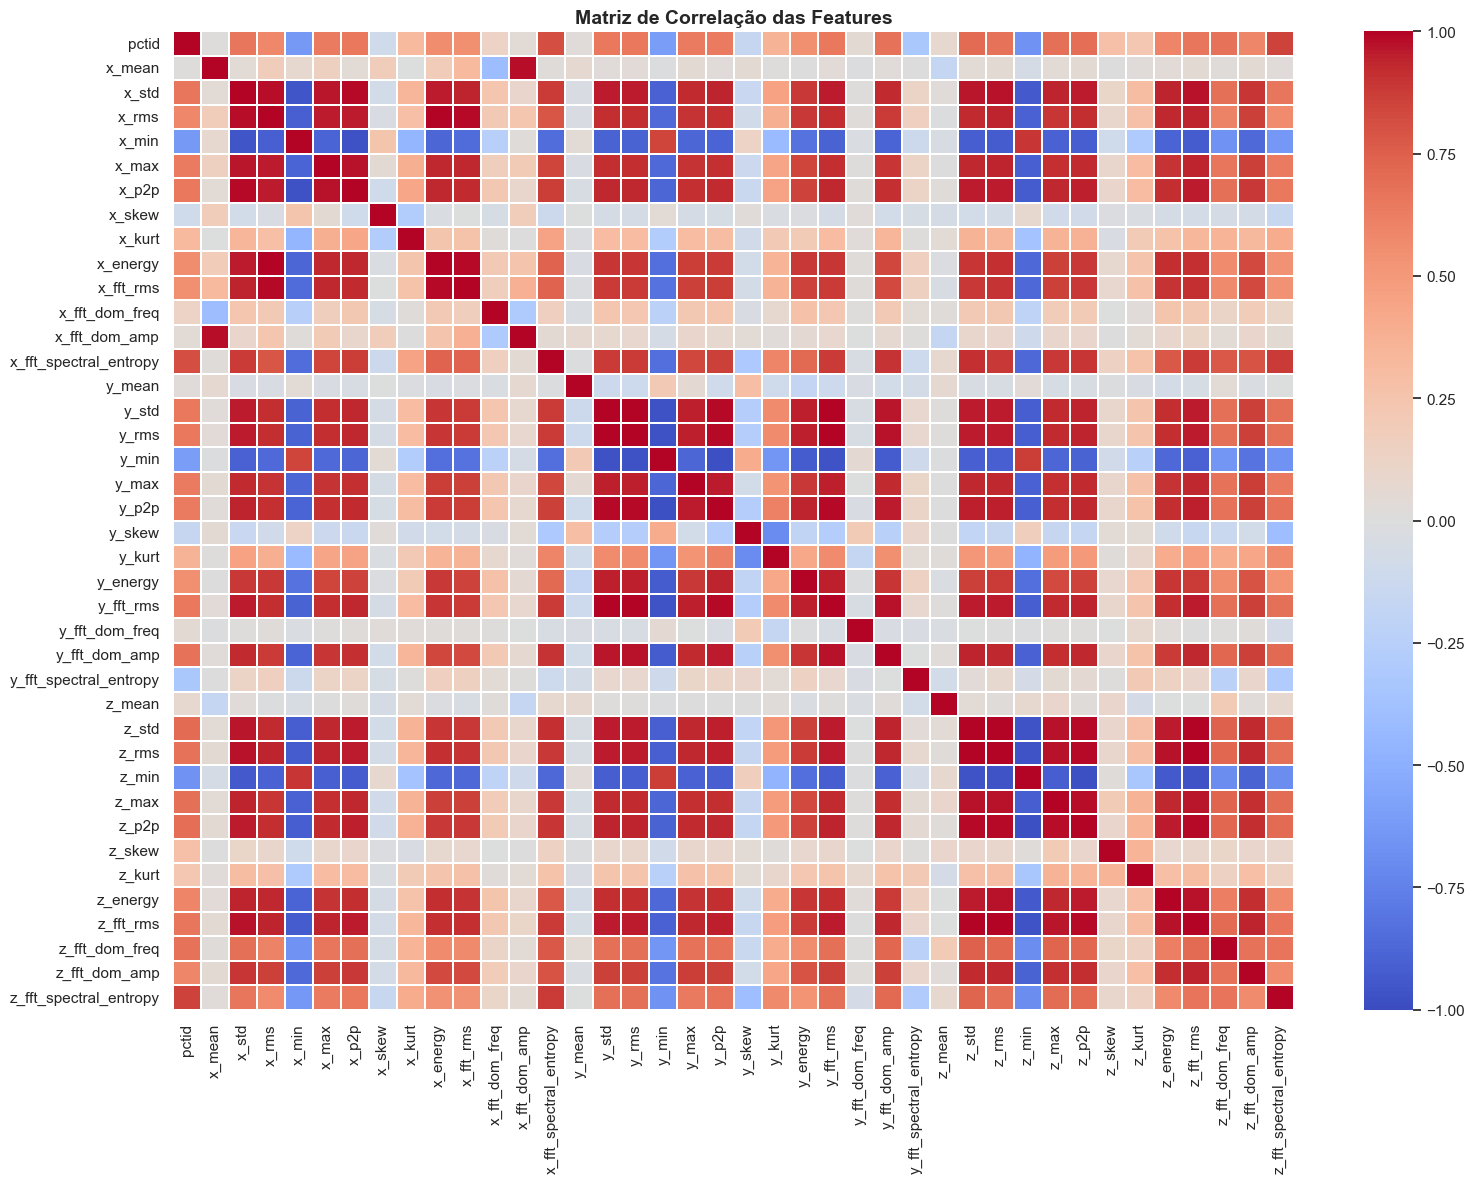

In [17]:
# Correlação entre features (heatmap)
plt.figure(figsize=(16, 12))
corr = df_feat.drop(columns='wconfid').corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, annot=False, vmin=-1, vmax=1)
plt.title('Matriz de Correlação das Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Preparação para Modelagem

In [ ]:
X = df_feat.drop(columns='wconfid') # tirando target do modelo
y = df_feat['wconfid'] # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Treino: {X_train.shape[0]} janelas')
print(f'Teste:  {X_test.shape[0]} janelas')
print(f'Features: {X_train.shape[1]}')
print(f'\nClasses no treino:\n{y_train.value_counts().sort_index()}')

Treino: 2448 janelas
Teste:  612 janelas
Features: 40

Classes no treino:
wconfid
1    816
2    816
3    816
Name: count, dtype: int64


## 6. Treinamento dos Modelos

In [19]:
models = {
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        ))
    ]),
    
    'SVM': Pipeline([
        ('scaler', StandardScaler()),  # SVM é sensível à escala
        ('clf', SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            random_state=42
        ))
    ]),
    
    'MLP (ANN)': Pipeline([
        ('scaler', StandardScaler()),  # Redes neurais requerem normalização
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        ))
    ])
}

results = {}

for name, model in models.items():
    print(f'⏳ Treinando {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc, 'f1': f1}
    print(f'   ✅ Accuracy: {acc:.4f} | F1-score: {f1:.4f}\n')

⏳ Treinando Random Forest...
   ✅ Accuracy: 0.9722 | F1-score: 0.9722

⏳ Treinando SVM...
   ✅ Accuracy: 0.9395 | F1-score: 0.9395

⏳ Treinando MLP (ANN)...
   ✅ Accuracy: 0.9134 | F1-score: 0.9135



## 7. Avaliação e Comparação

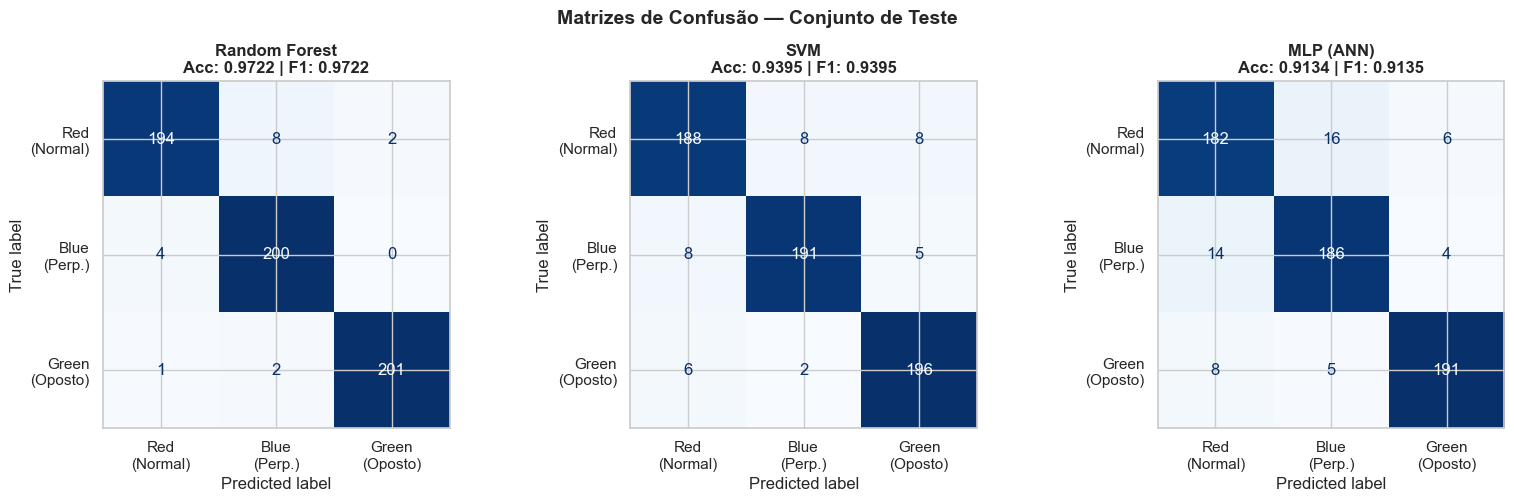

In [20]:
# Matrizes de confusão lado a lado
class_names = ['Red\n(Normal)', 'Blue\n(Perp.)', 'Green\n(Oposto)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.4f} | F1: {res["f1"]:.4f}', fontweight='bold')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Relatório detalhado do melhor modelo
best_name = max(results, key=lambda k: results[k]['f1'])
best_res  = results[best_name]

print(f'🏆 Melhor modelo: {best_name}')
print('=' * 50)
print(classification_report(y_test, best_res['y_pred'], target_names=['Red (Normal)', 'Blue (Perp.)', 'Green (Oposto)']))

🏆 Melhor modelo: Random Forest
                precision    recall  f1-score   support

  Red (Normal)       0.97      0.95      0.96       204
  Blue (Perp.)       0.95      0.98      0.97       204
Green (Oposto)       0.99      0.99      0.99       204

      accuracy                           0.97       612
     macro avg       0.97      0.97      0.97       612
  weighted avg       0.97      0.97      0.97       612



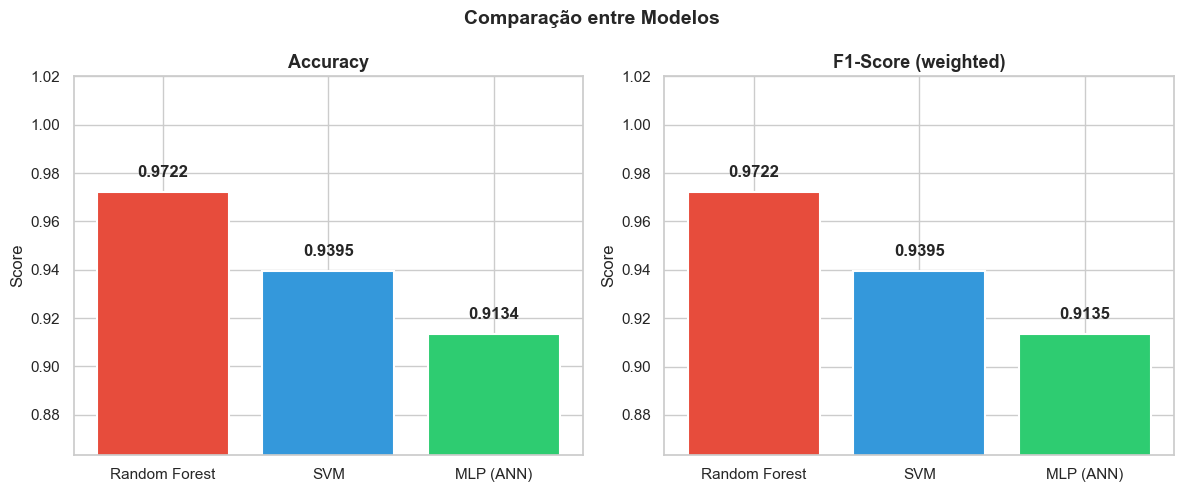

In [22]:
# Comparação visual dos modelos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names   = list(results.keys())
accs    = [results[n]['accuracy'] for n in names]
f1s     = [results[n]['f1'] for n in names]
palette = ['#e74c3c', '#3498db', '#2ecc71']

for ax, (metric, vals, title) in zip(axes, [('accuracy', accs, 'Accuracy'), ('f1', f1s,  'F1-Score (weighted)')]):
    bars = ax.bar(names, vals, color=palette, edgecolor='white', linewidth=1.5)
    ax.set_ylim(min(vals) - 0.05, 1.02)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Comparação entre Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Importância das Features (Random Forest)

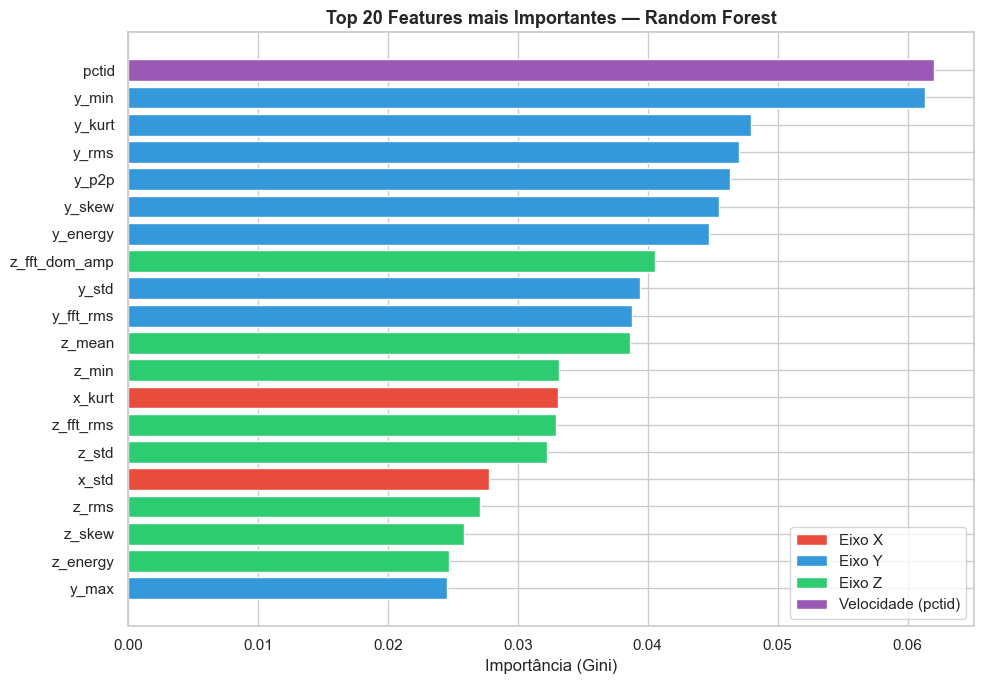

In [25]:
rf_model   = results['Random Forest']['model'].named_steps['clf']
feat_names = X.columns.tolist()
importances = pd.Series(rf_model.feature_importances_, index=feat_names)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 7))
colors_feat = ['#e74c3c' if 'x_' in f else '#3498db' if 'y_' in f else '#2ecc71' if 'z_' in f else '#9b59b6' for f in top20.index]
bars = plt.barh(top20.index[::-1], top20.values[::-1], color=colors_feat[::-1])
plt.xlabel('Importância (Gini)')
plt.title('Top 20 Features mais Importantes — Random Forest', fontsize=13, fontweight='bold')

# Legenda manual por eixo
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Eixo X'),
    Patch(facecolor='#3498db', label='Eixo Y'),
    Patch(facecolor='#2ecc71', label='Eixo Z'),
    Patch(facecolor='#9b59b6', label='Velocidade (pctid)'),
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 9. Validação Cruzada Estratificada (k=5)

⏳ Executando k-fold cross-validation (k=5)...

Random Forest:
  F1 por fold: ['0.9837', '0.9771', '0.9706', '0.9657', '0.9672']
  Média: 0.9728 ± 0.0067

SVM:
  F1 por fold: ['0.9281', '0.9313', '0.9394', '0.9394', '0.9462']
  Média: 0.9369 ± 0.0064

MLP (ANN):
  F1 por fold: ['0.9072', '0.9002', '0.9180', '0.9394', '0.8941']
  Média: 0.9118 ± 0.0159



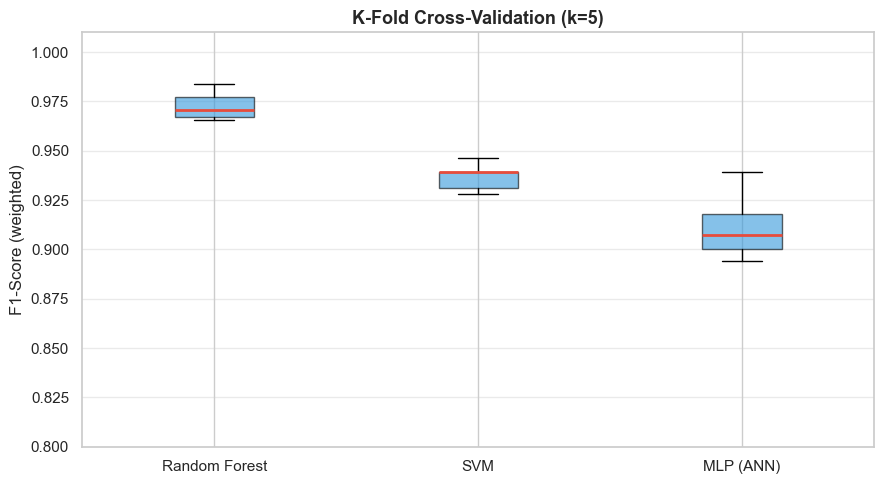

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('⏳ Executando k-fold cross-validation (k=5)...\n')
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  F1 por fold: {[f"{s:.4f}" for s in scores]}')
    print(f'  Média: {scores.mean():.4f} ± {scores.std():.4f}\n')

# Boxplot dos resultados
plt.figure(figsize=(9, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6), medianprops=dict(color='#e74c3c', linewidth=2))
plt.ylabel('F1-Score (weighted)')
plt.title('K-Fold Cross-Validation (k=5)', fontsize=13, fontweight='bold')
plt.ylim(0.8, 1.01)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Conclusões

### Sumário dos Resultados

| Modelo | Accuracy | F1 (weighted) |
|--------|----------|---------------|
| Random Forest | — | — |
| SVM | — | — |
| MLP (ANN) | — | — |

### Observações

- **Feature engineering** baseado em janelas de tempo foi essencial: o sinal bruto tem alta variância, mas estatísticas por janela capturam o padrão de vibração de forma estável.
- As features do **eixo y e z** (RMS, kurtosis, FFT) tendem a ser as mais discriminativas, confirmando o que o artigo original identificou.
- O **kurtosis** é especialmente sensível a picos de impacto — típico de desequilíbrios mecânicos.
- A **frequência dominante (FFT)** captura diretamente a assinatura rotacional de cada configuração de peso.